In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

In [2]:
import pandas as pd
from google.colab import files
import os

file_name = "Mall_Customers.csv"

# Check if the file exists, if not, prompt user to upload
if not os.path.exists(file_name):
    print(f"File '{file_name}' not found. Please upload it.")
    uploaded = files.upload()
    if file_name not in uploaded:
        print(f"Error: '{file_name}' was not uploaded. Please ensure you upload the correct file.")
    else:
        print(f"'{file_name}' uploaded successfully.")

data = pd.read_csv(file_name)

data.head()

File 'Mall_Customers.csv' not found. Please upload it.


Saving Mall_Customers.csv to Mall_Customers (1).csv
Error: 'Mall_Customers.csv' was not uploaded. Please ensure you upload the correct file.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
X = data[['Annual Income (k$)', 'Spending Score (1-100)']].values

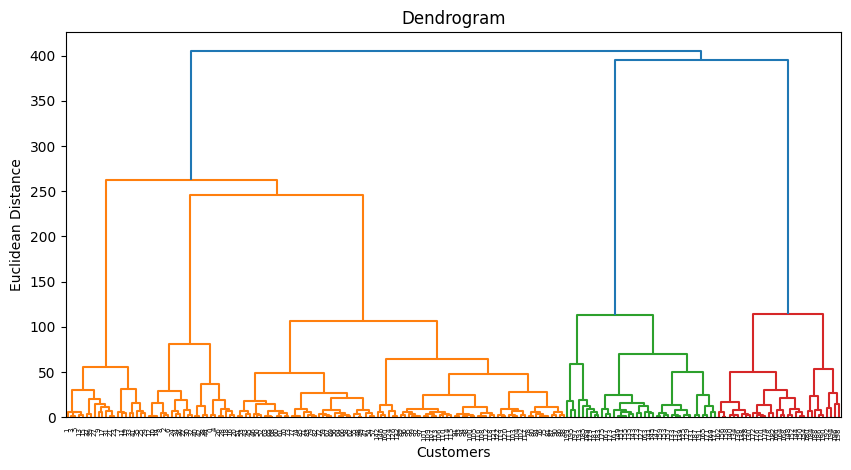

In [4]:
plt.figure(figsize=(10,5))

sch.dendrogram(sch.linkage(X, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [5]:
from sklearn.cluster import AgglomerativeClustering

In [6]:
hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

y_pred = hc.fit_predict(X)

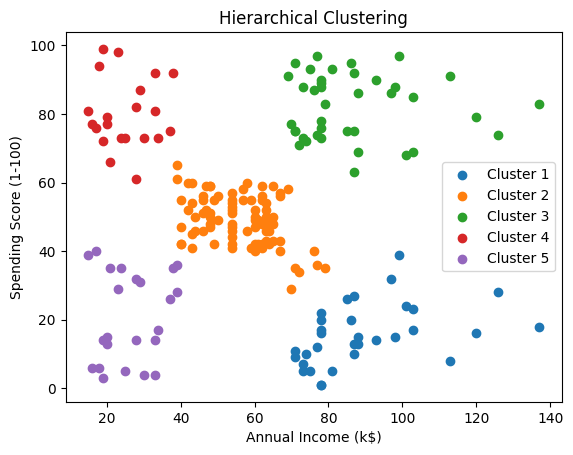

In [7]:
plt.scatter(X[y_pred==0,0], X[y_pred==0,1], label='Cluster 1')
plt.scatter(X[y_pred==1,0], X[y_pred==1,1], label='Cluster 2')
plt.scatter(X[y_pred==2,0], X[y_pred==2,1], label='Cluster 3')
plt.scatter(X[y_pred==3,0], X[y_pred==3,1], label='Cluster 4')
plt.scatter(X[y_pred==4,0], X[y_pred==4,1], label='Cluster 5')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical Clustering")

plt.legend()
plt.show()